In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings 
import seaborn as sns
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore') 


In [10]:
column_names = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
boston = pd.read_csv(r'C:\Users\tanri\Desktop\Phyton Files\Pandas Files\housing.csv', header= None, delimiter=r"\s+",names = column_names)

In [12]:
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [14]:
boston.head(2)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14,21.6


In [16]:
boston.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [18]:
df = boston[['RM','MEDV']]

In [24]:
df

,RM,MEDV
0,6.575,24.0
1,6.421,21.6
2,7.185,34.7
3,6.998,33.4
4,7.147,36.2
...,...,...
501,6.593,22.4
502,6.120,20.6
503,6.976,23.9
504,6.794,22.0


In [26]:
df.rename(columns = {'MEDV':'PRICE'}, inplace = True)

In [28]:
df

,RM,PRICE
0,6.575,24.0
1,6.421,21.6
2,7.185,34.7
3,6.998,33.4
4,7.147,36.2
...,...,...
501,6.593,22.4
502,6.120,20.6
503,6.976,23.9
504,6.794,22.0


In [30]:
df.describe()

,RM,PRICE
count,506.000000,506.000000
mean,6.284634,22.532806
std,0.702617,9.197104
min,3.561000,5.000000
25%,5.885500,17.025000
50%,6.208500,21.200000
75%,6.623500,25.000000
max,8.780000,50.000000


In [36]:
X = df['RM'].values.reshape(-1,1)
y = df['PRICE'].values.reshape(-1,1)

#2 değişken olsaydı mesela RM,ve Age bu sefer -1,2 yazmam gerekiyormuş. 

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)

In [60]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [62]:
y_train_predict = lr.predict(X_train)
train_rmse = (np.sqrt(mean_squared_error(y_train,y_train_predict)))
train_r2 = r2_score(y_train,y_train_predict) 
print("Performance of RMSE: ",train_rmse)
print("Performance of R2: " , train_r2)

Performance of RMSE:  6.709154529092623
Performance of R2:  0.4878892853275991


In [70]:
y_test_pred = lr.predict(X_test) 
test_rmse = (np.sqrt(mean_squared_error(y_test, y_test_pred)))
r2_test = r2_score(y_test,y_test_pred)
print("Test of RMSE : " , test_rmse)
print("Test of R2 : " , r2_test)

Test of RMSE :  6.352279094771659
Test of R2 :  0.4584649934303068


<function matplotlib.pyplot.show(close=None, block=None)>

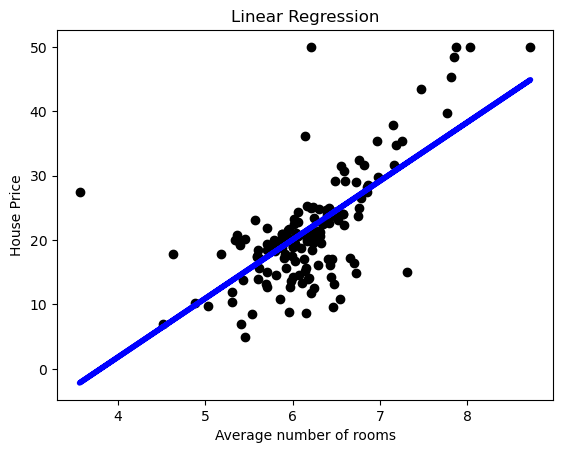

In [74]:
plt.scatter(X_test, y_test, color = 'black') 
plt.plot(X_test, y_test_pred, color = 'blue', linewidth = 4)
plt.xlabel('Average number of rooms')
plt.ylabel ('House Price')
plt.title ( 'Linear Regression')
plt.show 


In [86]:
rmse_test3 = np.sqrt(np.mean((y_test_pred - y_test)**2))
rmse_test3 

6.352279094771659

In [112]:
print('Coefficient : \n', lr.coef_)
print('Intercept : \n', lr.intercept_)
print('Root Mean Squarred Error: %2f ' % rmse_test3)
print('R Squared Value: %2f ' % r2_test)

Coefficient : 
 [[9.1181022]]
Intercept : 
 [-34.66230744]
Root Mean Squarred Error: 6.352279 
R Squared Value: 0.458465 


In [118]:
formula = ' y  = {:.2f}x'.format(lr.intercept_[0],lr.coef_[0][0])
print('Formula of linear Regression',formula)
                                 

Formula of linear Regression  y  = -34.66x
